<a href="https://colab.research.google.com/github/Rashmika-Bandara/Predicting-Customer-Spending-from-Demographics-and-Purchase-Frequency/blob/sadani/EE7209_Customer_Spending_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# DATA MANIPULATION
import pandas as pd
import numpy as np

# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [4]:
# GOOGLE DRIVE MOUNT
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
# LOAD DATA
df = pd.read_csv("/content/drive/MyDrive/customer_data.csv")
df.head()


,name,age,gender,education,income,country,purchase_frequency,spending
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780


In [6]:
# Check dataset structure
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                1000 non-null   object 
 1   age                 1000 non-null   int64  
 2   gender              1000 non-null   object 
 3   education           1000 non-null   object 
 4   income              1000 non-null   int64  
 5   country             1000 non-null   object 
 6   purchase_frequency  1000 non-null   float64
 7   spending            1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


,age,income,purchase_frequency,spending
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.754000,59277.852000,0.554600,9613.296835
std,13.778582,23258.377128,0.284675,5484.707210
min,18.000000,20031.000000,0.100000,611.985000
25%,30.000000,38825.500000,0.300000,5020.425000
50%,42.000000,58972.000000,0.600000,9430.395000
75%,54.000000,79114.000000,0.800000,13645.507500
max,65.000000,99780.000000,1.000000,25546.500000


In [ ]:
# View all column names in the dataset
df.columns


Index(['name', 'age', 'gender', 'education', 'income', 'country',
       'purchase_frequency', 'spending'],
      dtype='object')

In [8]:
# Drop the name column because it's just an identifier
df = df.drop(columns=['name'])


In [9]:
# Check for missing values
df.isnull().sum()


,0
age,0
gender,0
education,0
income,0
country,0
purchase_frequency,0
spending,0


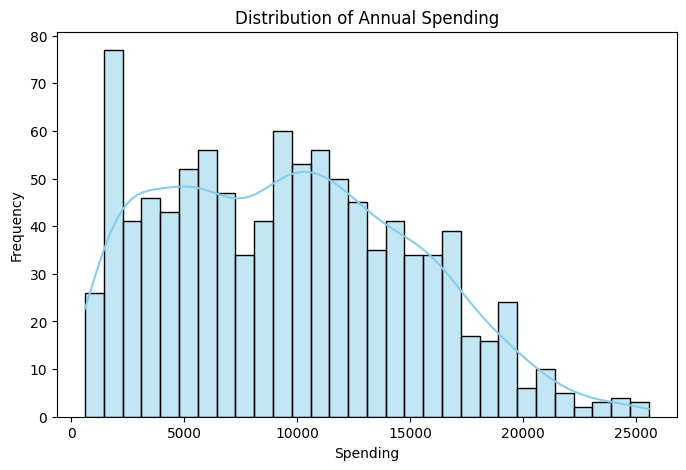

In [ ]:
# Plot the distribution of annual customer spending
plt.figure(figsize=(8,5))
sns.histplot(df['spending'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Annual Spending")
plt.xlabel("Spending")
plt.ylabel("Frequency")
plt.show()



Slightly Right-skewed(Many customers spend less,Few customers spend very high amounts)

In [ ]:
# Calculate skewness of the spending distribution
df['spending'].skew()


np.float64(0.33511702033260965)

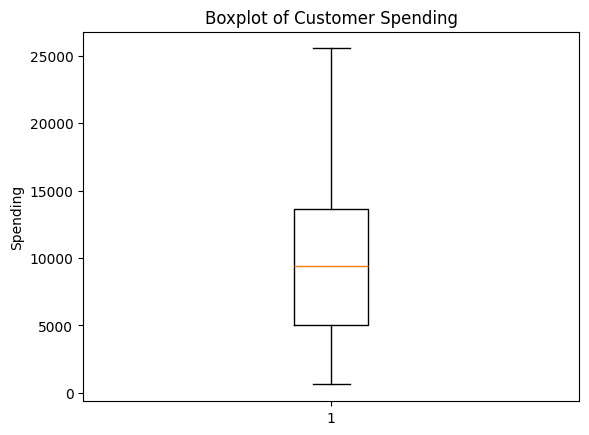

In [ ]:
# Visualize spending distribution with a boxplot to detect outliers
plt.boxplot(df['spending'])
plt.title("Boxplot of Customer Spending")
plt.ylabel("Spending")
plt.show()


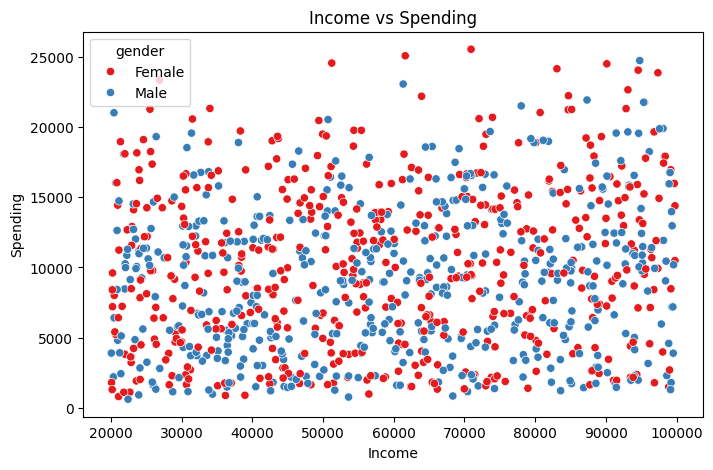

In [ ]:
# Explore relationship between income and spending, colored by gender
plt.figure(figsize=(8,5))
sns.scatterplot(x='income', y='spending', data=df, hue='gender', palette='Set1')
plt.title("Income vs Spending")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.show()


In [14]:
# Compute Pearson correlation
correlation = df['income'].corr(df['spending'])
print(f"Pearson Correlation between Income and Spending: {correlation:.4f}")


Pearson Correlation between Income and Spending: 0.1229


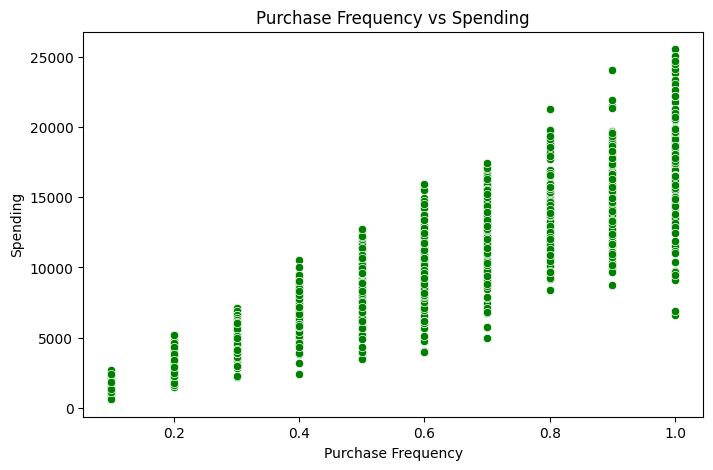

In [ ]:
# Explore relationship between purchase frequency and spending
plt.figure(figsize=(8,5))
sns.scatterplot(x='purchase_frequency', y='spending', data=df, color='green')
plt.title("Purchase Frequency vs Spending")
plt.xlabel("Purchase Frequency")
plt.ylabel("Spending")
plt.show()


In [ ]:
# Measure correlation between purchase frequency and spending
corr_pf = df['purchase_frequency'].corr(df['spending'])
print(f"Correlation between Purchase Frequency and Spending: {corr_pf:.4f}")


Correlation between Purchase Frequency and Spending: 0.8952


/tmp/ipykernel_1239/2718001272.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='spending', data=df, palette='pastel')


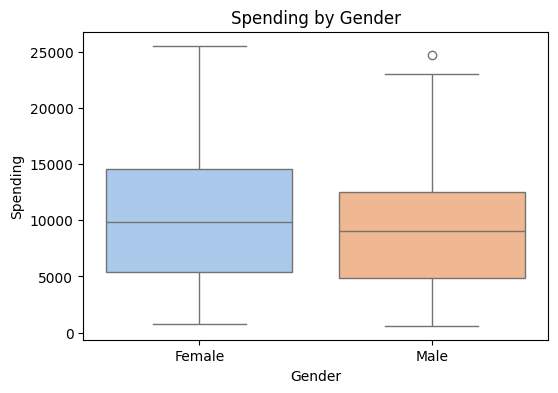

In [ ]:
# Compare spending distributions across genders
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='spending', data=df, palette='pastel')
plt.title("Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Spending")
plt.show()


In [ ]:
# Summary statistics of spending grouped by gender
gender_stats = df.groupby('gender')['spending'].describe()
print(gender_stats)


        count          mean          std      min        25%       50%  \
gender                                                                   
Female  499.0  10183.117214  5757.790329  805.290  5402.0575  9857.925   
Male    501.0   9045.751188  5141.743217  611.985  4903.5400  9023.455   

              75%      max  
gender                      
Female  14537.195  25546.5  
Male    12489.720  24739.8  


In [ ]:
# Encode gender as numerical and check its correlation with spending
df['gender_encoded'] = df['gender'].map({'Male':1, 'Female':0})

corr_gender = df['gender_encoded'].corr(df['spending'])
print(f"Correlation between Gender and Spending: {corr_gender:.4f}")


Correlation between Gender and Spending: -0.1037


/tmp/ipykernel_1239/3732408827.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='education', y='spending', data=df, palette='cool')


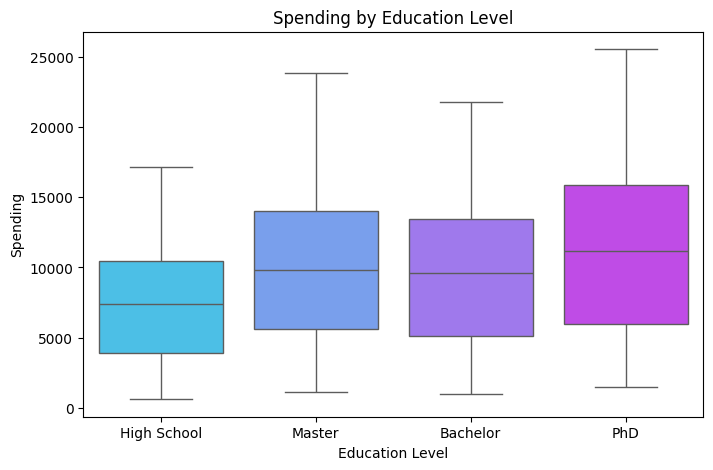

In [ ]:
# Compare spending across different education levels
plt.figure(figsize=(8,5))
sns.boxplot(x='education', y='spending', data=df, palette='cool')
plt.title("Spending by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Spending")
plt.show()


In [ ]:
# Summary statistics of spending grouped by education level
education_stats = df.groupby('education')['spending'].describe()
print(education_stats)


             count          mean          std       min         25%  \
education                                                             
Bachelor     271.0   9522.349410  5262.978526   971.685  5080.99000   
High School  245.0   7521.557837  4225.960097   611.985  3918.19500   
Master       236.0  10167.478326  5431.063456  1143.610  5628.31625   
PhD          248.0  11251.748347  6192.449811  1502.335  5967.28500   

                    50%          75%       max  
education                                       
Bachelor      9581.9100  13478.27750  21773.35  
High School   7382.3600  10454.24000  17125.45  
Master        9812.7675  14047.47375  23868.40  
PhD          11178.1750  15899.00750  25546.50  


In [ ]:
# Perform one-way ANOVA to test if mean spending differs by education level
from scipy.stats import f_oneway

groups = [group["spending"].values
          for name, group in df.groupby("education")]

anova_result = f_oneway(*groups)
print("ANOVA F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)


ANOVA F-statistic: 21.308220683605093
p-value: 2.2101587291199794e-13


In [ ]:
# Mean spending for each education level
df.groupby('education')['spending'].mean()


,spending
education,
Bachelor,9522.349410
High School,7521.557837
Master,10167.478326
PhD,11251.748347


In [24]:
# Features (X) and Target (y)
X = df.drop(columns=['spending'])
y = df['spending']


In [ ]:
# Preview feature matrix X and target vector y
X.head()
y.head()


,spending
0,13227.120
1,12674.040
2,5354.115
3,2606.510
4,18984.780


In [26]:
# List of numeric and categorical features
numeric_features = ['age', 'income', 'purchase_frequency']
categorical_features = ['gender', 'education', 'country']


In [ ]:
# Build preprocessing pipeline: scale numeric features and one-hot encode categoricals
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
)


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
#Pipeline ensures preprocessing happens automatically when training/testing.

In [ ]:
# Split data into training and test sets for model evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [30]:
# Train Linear Regression
lr_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'income',
                                                   'purchase_frequency']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'education',
                                                   'country'])])),
                ('regressor', LinearRegression())])

In [ ]:
# Generate predictions on the test set using the trained Linear Regression model
y_pred_lr = lr_pipeline.predict(X_test)



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
# Evaluate Linear Regression model performance on the test set
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2 Score:", r2_lr)


Linear Regression Performance:
RMSE: 1441.9853920643502
MAE: 1101.6732230763969
R2 Score: 0.9311374552148342


In [ ]:
# Compute average customer spending as a simple baseline
df['spending'].mean()


np.float64(9613.296835000001)

In [34]:
# Compare MAE with average spending

mean_spending = df['spending'].mean()

print("Average Spending:", mean_spending)

print("MAE as % of mean spending:",
      (mae_lr / mean_spending) * 100)


Average Spending: 9613.296835000001
MAE as % of mean spending: 11.459889796239677


In [ ]:
# Train Random Forest model on the training data
rf_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'income',
                                                   'purchase_frequency']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'education',
                                                   'country'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [ ]:
# Generate predictions on the test set using the trained Random Forest model
y_pred_rf = rf_pipeline.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
# Evaluate Random Forest model performance on the test set
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2 Score:", r2_rf)


Random Forest Performance:
RMSE: 871.5761980111248
MAE: 653.5402577500003
R2 Score: 0.9748422342341073


In [38]:
# MAE as % of mean spending (Random Forest)
mean_spending = df['spending'].mean()
print("MAE as % of mean spending (RF):", (mae_rf / mean_spending) * 100)

MAE as % of mean spending (RF): 6.798294788636891


In [39]:
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Cross-validate Random Forest and compute feature importances
from sklearn.model_selection import cross_val_score

cv_rf = cross_val_score(rf_pipeline, X, y, cv=5, scoring='r2')
print("Random Forest CV R²:", cv_rf.mean())
rf_model = rf_pipeline.named_steps['regressor']
importances = rf_model.feature_importances_
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)


Random Forest CV R²: 0.9764465470243046


,Feature,Importance
2,num__purchase_frequency,0.799229
0,num__age,0.073787
4,cat__education_High School,0.048012
6,cat__education_PhD,0.040169
1,num__income,0.019133
3,cat__gender_Male,0.005348
5,cat__education_Master,0.003122
27,cat__country_Belize,0.000417
72,cat__country_Ethiopia,0.000396
239,cat__country_Zambia,0.000379


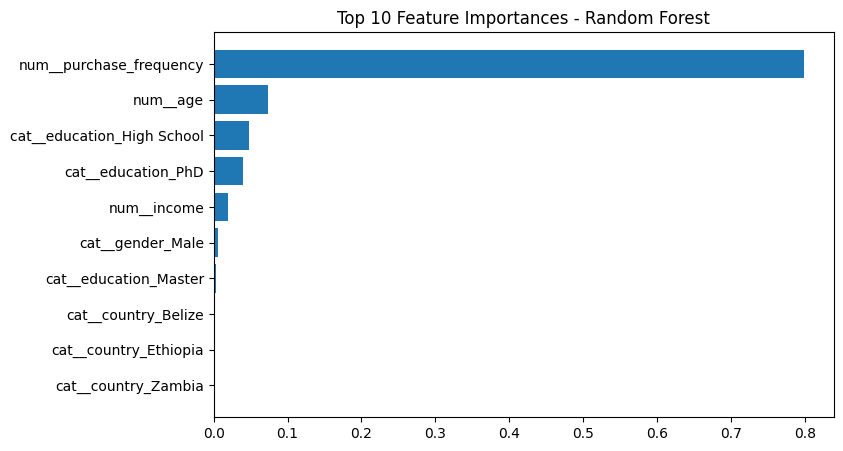

In [ ]:
# Visualize top Random Forest feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'][:10],
         feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()


In [ ]:
# Tabular comparison of Linear Regression and Random Forest performance
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE': [mae_lr, mae_rf],
    'R2 Score': [r2_lr, r2_rf]
})

comparison


,Model,RMSE,MAE,R2 Score
0,Linear Regression,1441.985392,1101.673223,0.931137
1,Random Forest,871.576198,653.540258,0.974842


In [43]:
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Perform 5-fold cross-validation for both models and compare mean R²
from sklearn.model_selection import cross_val_score

cv_lr = cross_val_score(lr_pipeline, X, y,
                        cv=5, scoring='r2')

cv_rf = cross_val_score(rf_pipeline, X, y,
                        cv=5, scoring='r2')

print("Linear Regression CV R2:", cv_lr.mean())
print("Random Forest CV R2:", cv_rf.mean())


Linear Regression CV R2: 0.9317558042609232
Random Forest CV R2: 0.9764465470243046


In [ ]:
# Extended comparison table including cross-validated R² for both models
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE': [mae_lr, mae_rf],
    'R2 Score': [r2_lr, r2_rf],
    'CV R2': [cv_lr.mean(), cv_rf.mean()]
})
comparison


,Model,RMSE,MAE,R2 Score,CV R2
0,Linear Regression,1441.985392,1101.673223,0.931137,0.931756
1,Random Forest,871.576198,653.540258,0.974842,0.976447


In [ ]:
# Recompute Random Forest feature importances using the fitted pipeline
rf_model = rf_pipeline.named_steps['regressor']

importances = rf_model.feature_importances_

# Get feature names after preprocessing
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)


,Feature,Importance
2,num__purchase_frequency,0.799229
0,num__age,0.073787
4,cat__education_High School,0.048012
6,cat__education_PhD,0.040169
1,num__income,0.019133
3,cat__gender_Male,0.005348
5,cat__education_Master,0.003122
27,cat__country_Belize,0.000417
72,cat__country_Ethiopia,0.000396
239,cat__country_Zambia,0.000379


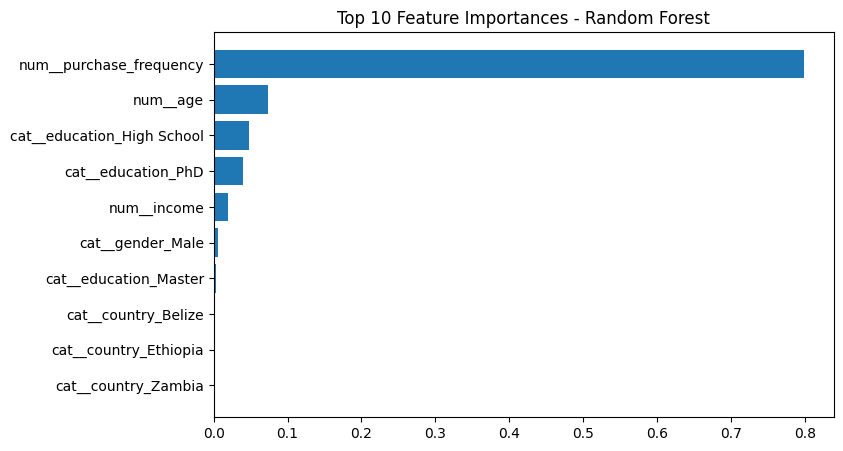

In [ ]:
# Plot top 10 Random Forest feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'][:10],
         feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()


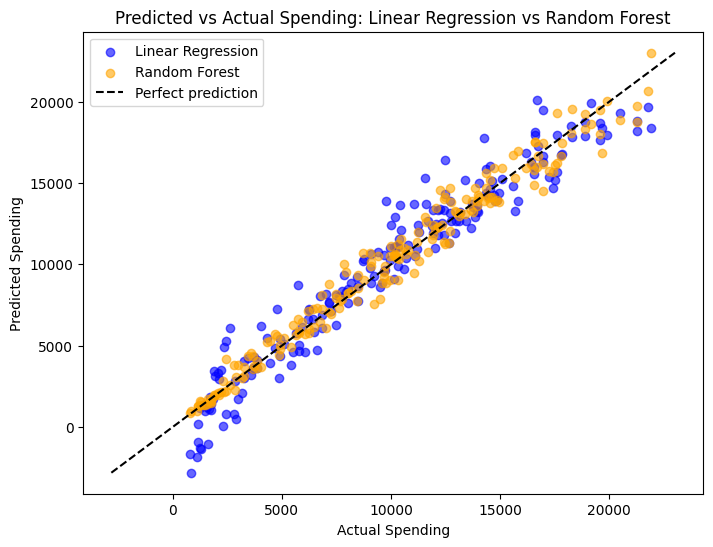

In [48]:
# Predicted vs Actual plots for Linear Regression and Random Forest
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, label='Linear Regression', color='blue')
plt.scatter(y_test, y_pred_rf, alpha=0.6, label='Random Forest', color='orange')
max_val = max(y_test.max(), y_pred_lr.max(), y_pred_rf.max())
min_val = min(y_test.min(), y_pred_lr.min(), y_pred_rf.min())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect prediction')
plt.xlabel('Actual Spending')
plt.ylabel('Predicted Spending')
plt.title('Predicted vs Actual Spending: Linear Regression vs Random Forest')
plt.legend()
plt.show()

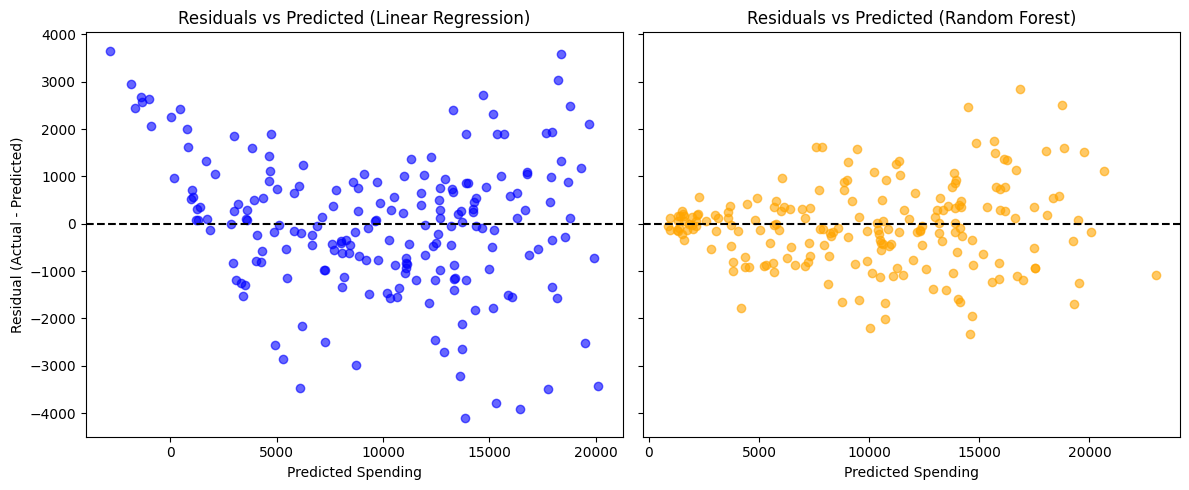

In [49]:
# Residuals vs Predicted plots for both models
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

axes[0].scatter(y_pred_lr, residuals_lr, alpha=0.6, color='blue')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuals vs Predicted (Linear Regression)')
axes[0].set_xlabel('Predicted Spending')
axes[0].set_ylabel('Residual (Actual - Predicted)')

axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.6, color='orange')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residuals vs Predicted (Random Forest)')
axes[1].set_xlabel('Predicted Spending')

plt.tight_layout()
plt.show()

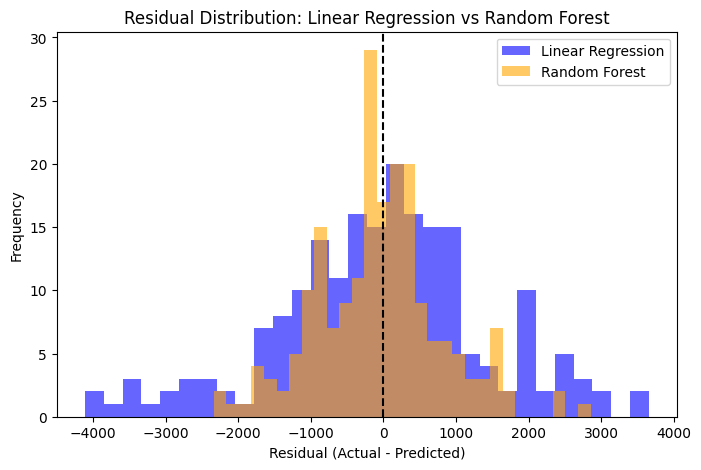

In [50]:
# Residual distribution histograms for both models
plt.figure(figsize=(8,5))
plt.hist(residuals_lr, bins=30, alpha=0.6, label='Linear Regression', color='blue')
plt.hist(residuals_rf, bins=30, alpha=0.6, label='Random Forest', color='orange')
plt.axvline(0, color='black', linestyle='--')
plt.title('Residual Distribution: Linear Regression vs Random Forest')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

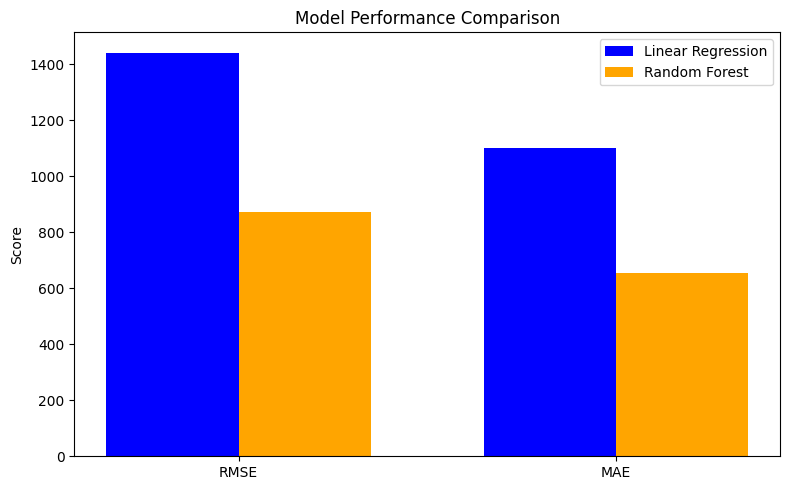

In [55]:
# Model comparison bar charts for RMSE, MAE, and R²
metrics = ['RMSE', 'MAE']
lr_scores = [rmse_lr, mae_lr]
rf_scores = [rmse_rf, mae_rf]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, lr_scores, width, label='Linear Regression', color='blue')
ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
plt.tight_layout()
plt.show()

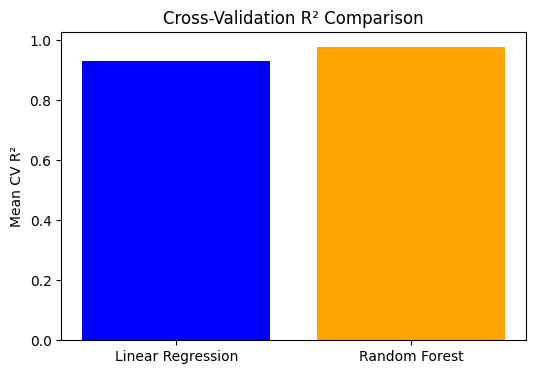

In [52]:
# Cross-validation mean R² comparison for both models
cv_scores = [cv_lr.mean(), cv_rf.mean()]
models = ['Linear Regression', 'Random Forest']

plt.figure(figsize=(6,4))
plt.bar(models, cv_scores, color=['blue', 'orange'])
plt.ylabel('Mean CV R²')
plt.title('Cross-Validation R² Comparison')
plt.ylim(0, max(cv_scores) + 0.05)
plt.show()

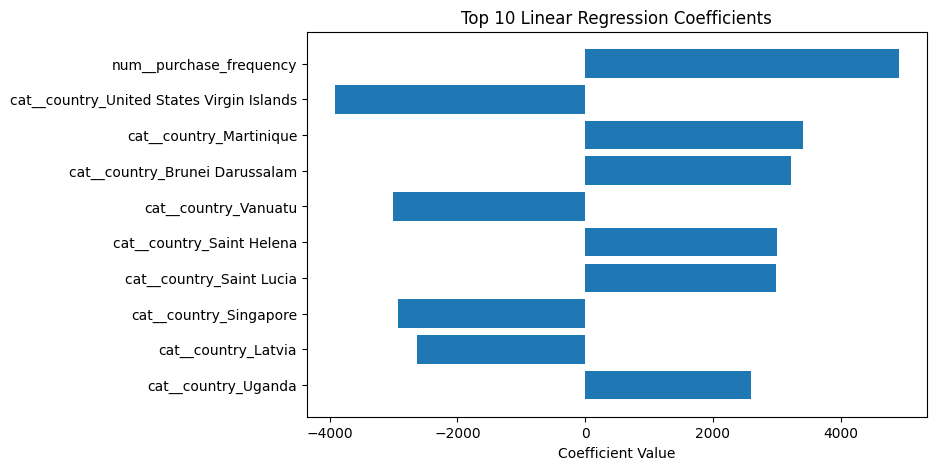

In [53]:
# Coefficient magnitude plot for Linear Regression
lin_reg = lr_pipeline.named_steps['regressor']
lr_feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = lin_reg.coef_
coef_df = pd.DataFrame({'Feature': lr_feature_names, 'Coefficient': coefficients})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
top_coef_df = coef_df.sort_values('AbsCoefficient', ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(top_coef_df['Feature'], top_coef_df['Coefficient'])
plt.gca().invert_yaxis()
plt.title('Top 10 Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.show()

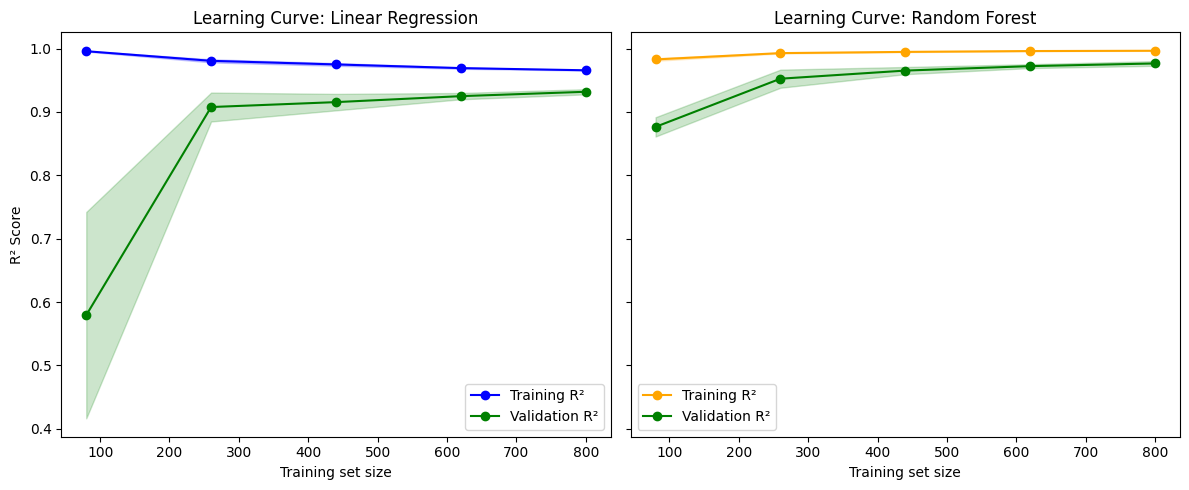

In [56]:
# Learning curves for Linear Regression and Random Forest
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 5)

# Learning curve for Linear Regression
train_sizes_lr, train_scores_lr, val_scores_lr = learning_curve(
    lr_pipeline, X, y, cv=5, scoring='r2', train_sizes=train_sizes, n_jobs=-1
)

# Learning curve for Random Forest
train_sizes_rf, train_scores_rf, val_scores_rf = learning_curve(
    rf_pipeline, X, y, cv=5, scoring='r2', train_sizes=train_sizes, n_jobs=-1
)

train_mean_lr = train_scores_lr.mean(axis=1)
train_std_lr = train_scores_lr.std(axis=1)
val_mean_lr = val_scores_lr.mean(axis=1)
val_std_lr = val_scores_lr.std(axis=1)

train_mean_rf = train_scores_rf.mean(axis=1)
train_std_rf = train_scores_rf.std(axis=1)
val_mean_rf = val_scores_rf.mean(axis=1)
val_std_rf = val_scores_rf.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

axes[0].plot(train_sizes_lr, train_mean_lr, 'o-', color='blue', label='Training R²')
axes[0].fill_between(train_sizes_lr, train_mean_lr - train_std_lr, train_mean_lr + train_std_lr, alpha=0.2, color='blue')
axes[0].plot(train_sizes_lr, val_mean_lr, 'o-', color='green', label='Validation R²')
axes[0].fill_between(train_sizes_lr, val_mean_lr - val_std_lr, val_mean_lr + val_std_lr, alpha=0.2, color='green')
axes[0].set_title('Learning Curve: Linear Regression')
axes[0].set_xlabel('Training set size')
axes[0].set_ylabel('R² Score')
axes[0].legend()

axes[1].plot(train_sizes_rf, train_mean_rf, 'o-', color='orange', label='Training R²')
axes[1].fill_between(train_sizes_rf, train_mean_rf - train_std_rf, train_mean_rf + train_std_rf, alpha=0.2, color='orange')
axes[1].plot(train_sizes_rf, val_mean_rf, 'o-', color='green', label='Validation R²')
axes[1].fill_between(train_sizes_rf, val_mean_rf - val_std_rf, val_mean_rf + val_std_rf, alpha=0.2, color='green')
axes[1].set_title('Learning Curve: Random Forest')
axes[1].set_xlabel('Training set size')
axes[1].legend()

plt.tight_layout()
plt.show()